# 04 Graph comparators

GCN Direct and Physics-Residual GCN compare graph prediction with and without a physical residual path. Both use normalized adjacency following [Kipf and Welling](https://arxiv.org/abs/1609.02907).

The models use a maximum of 30 epochs, the same stopping criteria, three training-only topology folds and three random seeds. Early stopping within each OOF fold uses a topology subset of that fold's training data. These controls isolate graph and residual mechanisms within the implemented model family.

In [1]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
assert (PROJECT / "src" / "models.py").is_file()
sys.path.insert(0, str(PROJECT))
from src.notebook_tools import configure_style, show_table, save_figure
from src.protocol import SEED, SEEDS, FULL_CONFIG, TRAINING, MODEL_ORDER

configure_style()
rng = np.random.default_rng(SEED)
FIGURES = PROJECT / "figures"
TABLES = PROJECT / "artifacts" / "generated" / "tables"
RESULTS = PROJECT / "artifacts" / "generated" / "results"
MODELS = PROJECT / "artifacts" / "generated" / "models"
for directory in (FIGURES, TABLES, RESULTS, MODELS):
    directory.mkdir(parents=True, exist_ok=True)


from src.models import DatasetBundle, load_bundle, split_indices, predict_graph_model
from src.protocol import (
    regression_metrics,
    probability_metrics,
    fit_tabular,
    predict_tabular,
    train_graph,
    save_graph,
    inner_group_selection,
    measure_resources,
    cluster_bootstrap,
    holm_adjust,
    calibrate_probability,
)

bundle = load_bundle(PROJECT / "dataset" / "processed")
metadata = bundle.metadata
indices = split_indices(bundle)
all_indices = np.arange(len(metadata))
valid_test = indices["test"][metadata.iloc[indices["test"]].converged.to_numpy() == 1]
fold_manifest = pd.read_csv(PROJECT / "dataset" / "processed" / "topology_folds.csv")
fold_id = fold_manifest.set_index("sample_id").loc[metadata.sample_id, "fold"].to_numpy()


def prediction_path(name: str) -> Path:
    """Use the same unambiguous model identifier throughout the study."""
    return RESULTS / (name.replace(" ", "_") + "_predictions.npz")


def load_predictions(name: str) -> tuple[np.ndarray, np.ndarray]:
    stored = np.load(prediction_path(name))
    assert np.array_equal(stored["sample_id"], metadata.sample_id.to_numpy())
    return stored["prediction"], stored["probability"]

In [2]:
configs = {
    "GCN Direct": dict(
        hidden=40,
        use_graph=True,
        use_reliability=False,
        use_physics_residual=False,
        use_multitask=True,
        simple_fusion=True,
    ),
    "Physics-Residual GCN": dict(
        hidden=40,
        use_graph=True,
        use_reliability=False,
        use_physics_residual=True,
        use_multitask=True,
        simple_fusion=False,
    ),
}
graph_regression, graph_probability, graph_oof, graph_seed_rows, graph_efficiency = (
    [],
    [],
    [],
    [],
    [],
)
graph_models = {}
training = indices["train"]


def run_graph_control(name: str) -> pd.DataFrame:
    """Evaluate one fixed graph control with nested group stopping."""
    configuration = configs[name]
    oof_prediction = np.full((len(training), 2), np.nan)
    oof_probability = np.full(len(training), np.nan)
    for fold in range(3):
        fold_training = training[fold_id[training] != fold]
        held = training[fold_id[training] == fold]
        fit, select = inner_group_selection(bundle, fold_training, SEED + fold)
        trained = train_graph(bundle, fit, select, configuration, **TRAINING)
        prediction, probability, _ = predict_graph_model(trained, bundle, held)
        positions = np.flatnonzero(fold_id[training] == fold)
        oof_prediction[positions], oof_probability[positions] = prediction, probability
        graph_oof.append(
            dict(
                model=name,
                split="training OOF",
                fold=fold,
                n=len(held),
                **regression_metrics(bundle.targets[held], prediction)
            )
        )
    assert np.isfinite(oof_prediction).all()
    stem = name.replace(" ", "_")
    np.savez_compressed(
        RESULTS / (stem + "_oof.npz"),
        sample_id=metadata.sample_id.to_numpy()[training],
        fold=fold_id[training],
        prediction=oof_prediction,
        probability=oof_probability,
    )
    with measure_resources() as resources:
        trained = train_graph(bundle, training, indices["selection"], configuration, **TRAINING)
    graph_models[name] = trained
    save_graph(trained, MODELS / (stem + ".pt"), bundle)
    trained.train_history.to_csv(RESULTS / (stem + "_history.csv"), index=False)
    prediction, probability, _ = predict_graph_model(trained, bundle, all_indices)
    np.savez_compressed(
        prediction_path(name),
        sample_id=metadata.sample_id.to_numpy(),
        prediction=prediction,
        probability=probability,
    )
    for split in ["selection", "test", "external"]:
        selected = indices[split]
        valid = selected[metadata.iloc[selected].converged.to_numpy() == 1]
        graph_regression.append(
            dict(
                model=name,
                split=split + " converged",
                n=len(valid),
                **regression_metrics(bundle.targets[valid], prediction[valid])
            )
        )
        graph_probability.append(
            dict(
                model=name,
                split=split,
                n=len(selected),
                **probability_metrics(bundle.targets[selected, 2], probability[selected])
            )
        )
    for seed in SEEDS[:3]:
        member = (
            trained
            if seed == SEED
            else train_graph(
                bundle, training, indices["selection"], configuration, seed=seed, **TRAINING
            )
        )
        seed_prediction, _, _ = predict_graph_model(member, bundle, valid_test)
        graph_seed_rows.append(
            dict(
                model=name,
                split="test converged",
                seed=seed,
                n=len(valid_test),
                **regression_metrics(bundle.targets[valid_test], seed_prediction)
            )
        )
    timings = []
    for repeat in range(6):
        start = time.perf_counter()
        predict_graph_model(trained, bundle, indices["test"])
        if repeat:
            timings.append((time.perf_counter() - start) * 1000 / len(indices["test"]))
    graph_efficiency.append(
        dict(
            model=name,
            split="test",
            n=len(indices["test"]),
            train_time_s=resources.elapsed_s,
            inference_ms=float(np.median(timings)),
            inference_iqr_ms=float(np.subtract(*np.percentile(timings, [75, 25]))),
            peak_process_rss_mib=resources.peak_rss_mib,
            added_rss_mib=resources.incremental_rss_mib,
            serialized_mib=(MODELS / (stem + ".pt")).stat().st_size / 2**20,
            trainable_parameters=sum(
                parameter.numel() for parameter in trained.model.parameters()
            ),
        )
    )
    return pd.DataFrame([row for row in graph_oof if row["model"] == name])

## GCN Direct

The direct graph predictor is evaluated on withheld training topologies.

In [3]:
view = run_graph_control("GCN Direct")
show_table(
    view,
    ["model", "split", "fold", "n"],
    {
        "Voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "04_GCN_Direct_oof.csv",
    digits=6,
)

model,split,fold,n,vmin_rmse,vmin_mae,vmin_r2
GCN Direct,training OOF,0,715,0.027640,0.021014,0.783174
GCN Direct,training OOF,1,714,0.016980,0.013405,0.880989
GCN Direct,training OOF,2,717,0.022174,0.018638,0.899890
model,split,fold,n,loss_rmse_kw,loss_mae_kw,loss_r2
GCN Direct,training OOF,0,715,66.842888,36.774367,0.726795
GCN Direct,training OOF,1,714,46.698543,27.886262,0.818895
GCN Direct,training OOF,2,717,143.429366,75.004149,0.401488


Each held topology is excluded from both optimization and early stopping. OOF variation measures sensitivity to the training topology subset.

## Physics-Residual GCN

The graph residual predictor is evaluated on withheld training topologies.

In [4]:
view = run_graph_control("Physics-Residual GCN")
show_table(
    view,
    ["model", "split", "fold", "n"],
    {
        "Voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "04_Physics-Residual_GCN_oof.csv",
    digits=6,
)

model,split,fold,n,vmin_rmse,vmin_mae,vmin_r2
Physics-Residual GCN,training OOF,0,715,0.003409,0.002397,0.996702
Physics-Residual GCN,training OOF,1,714,0.003288,0.002562,0.995538
Physics-Residual GCN,training OOF,2,717,0.004432,0.003406,0.996000
model,split,fold,n,loss_rmse_kw,loss_mae_kw,loss_r2
Physics-Residual GCN,training OOF,0,715,9.685621,4.741612,0.994264
Physics-Residual GCN,training OOF,1,714,8.767644,4.561292,0.993616
Physics-Residual GCN,training OOF,2,717,18.708464,8.397622,0.989817


Each held topology is excluded from both optimization and early stopping. OOF variation measures sensitivity to the training topology subset.

In [5]:
for filename, records in [
    ("graph_regression.csv", graph_regression),
    ("graph_probability.csv", graph_probability),
    ("graph_oof.csv", graph_oof),
    ("graph_seeds.csv", graph_seed_rows),
    ("graph_efficiency.csv", graph_efficiency),
]:
    pd.DataFrame(records).to_csv(RESULTS / filename, index=False)

## Comparison with classical alternatives

Graph and classical models share the same converged holdout observations.

In [6]:
comparison = pd.concat(
    [pd.read_csv(RESULTS / "baseline_regression.csv"), pd.DataFrame(graph_regression)],
    ignore_index=True,
)
comparison = comparison[comparison.split.eq("test converged")]
show_table(
    comparison,
    ["model", "split", "n"],
    {
        "Voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "04_comparison.csv",
    digits=6,
)

model,split,n,vmin_rmse,vmin_mae,vmin_r2
LinearDistFlow,test converged,605,0.020858,0.008972,0.927410
Ridge,test converged,605,0.009549,0.003443,0.984784
RandomForest,test converged,605,0.013573,0.004190,0.969261
ExtraTrees,test converged,605,0.018995,0.005976,0.939796
MLP,test converged,605,0.011701,0.005446,0.977156
XGBoost,test converged,605,0.016909,0.004876,0.952292
LightGBM,test converged,605,0.016672,0.004202,0.953624
GCN Direct,test converged,605,0.023381,0.013531,0.908788
Physics-Residual GCN,test converged,605,0.008909,0.003787,0.986757
model,split,n,loss_rmse_kw,loss_mae_kw,loss_r2


The common holdout supports direct comparison of graph, tabular and physical predictors. Voltage and loss performance are evaluated separately.

## Optimization dynamics

Training objectives and selection errors describe convergence for both graph controls.

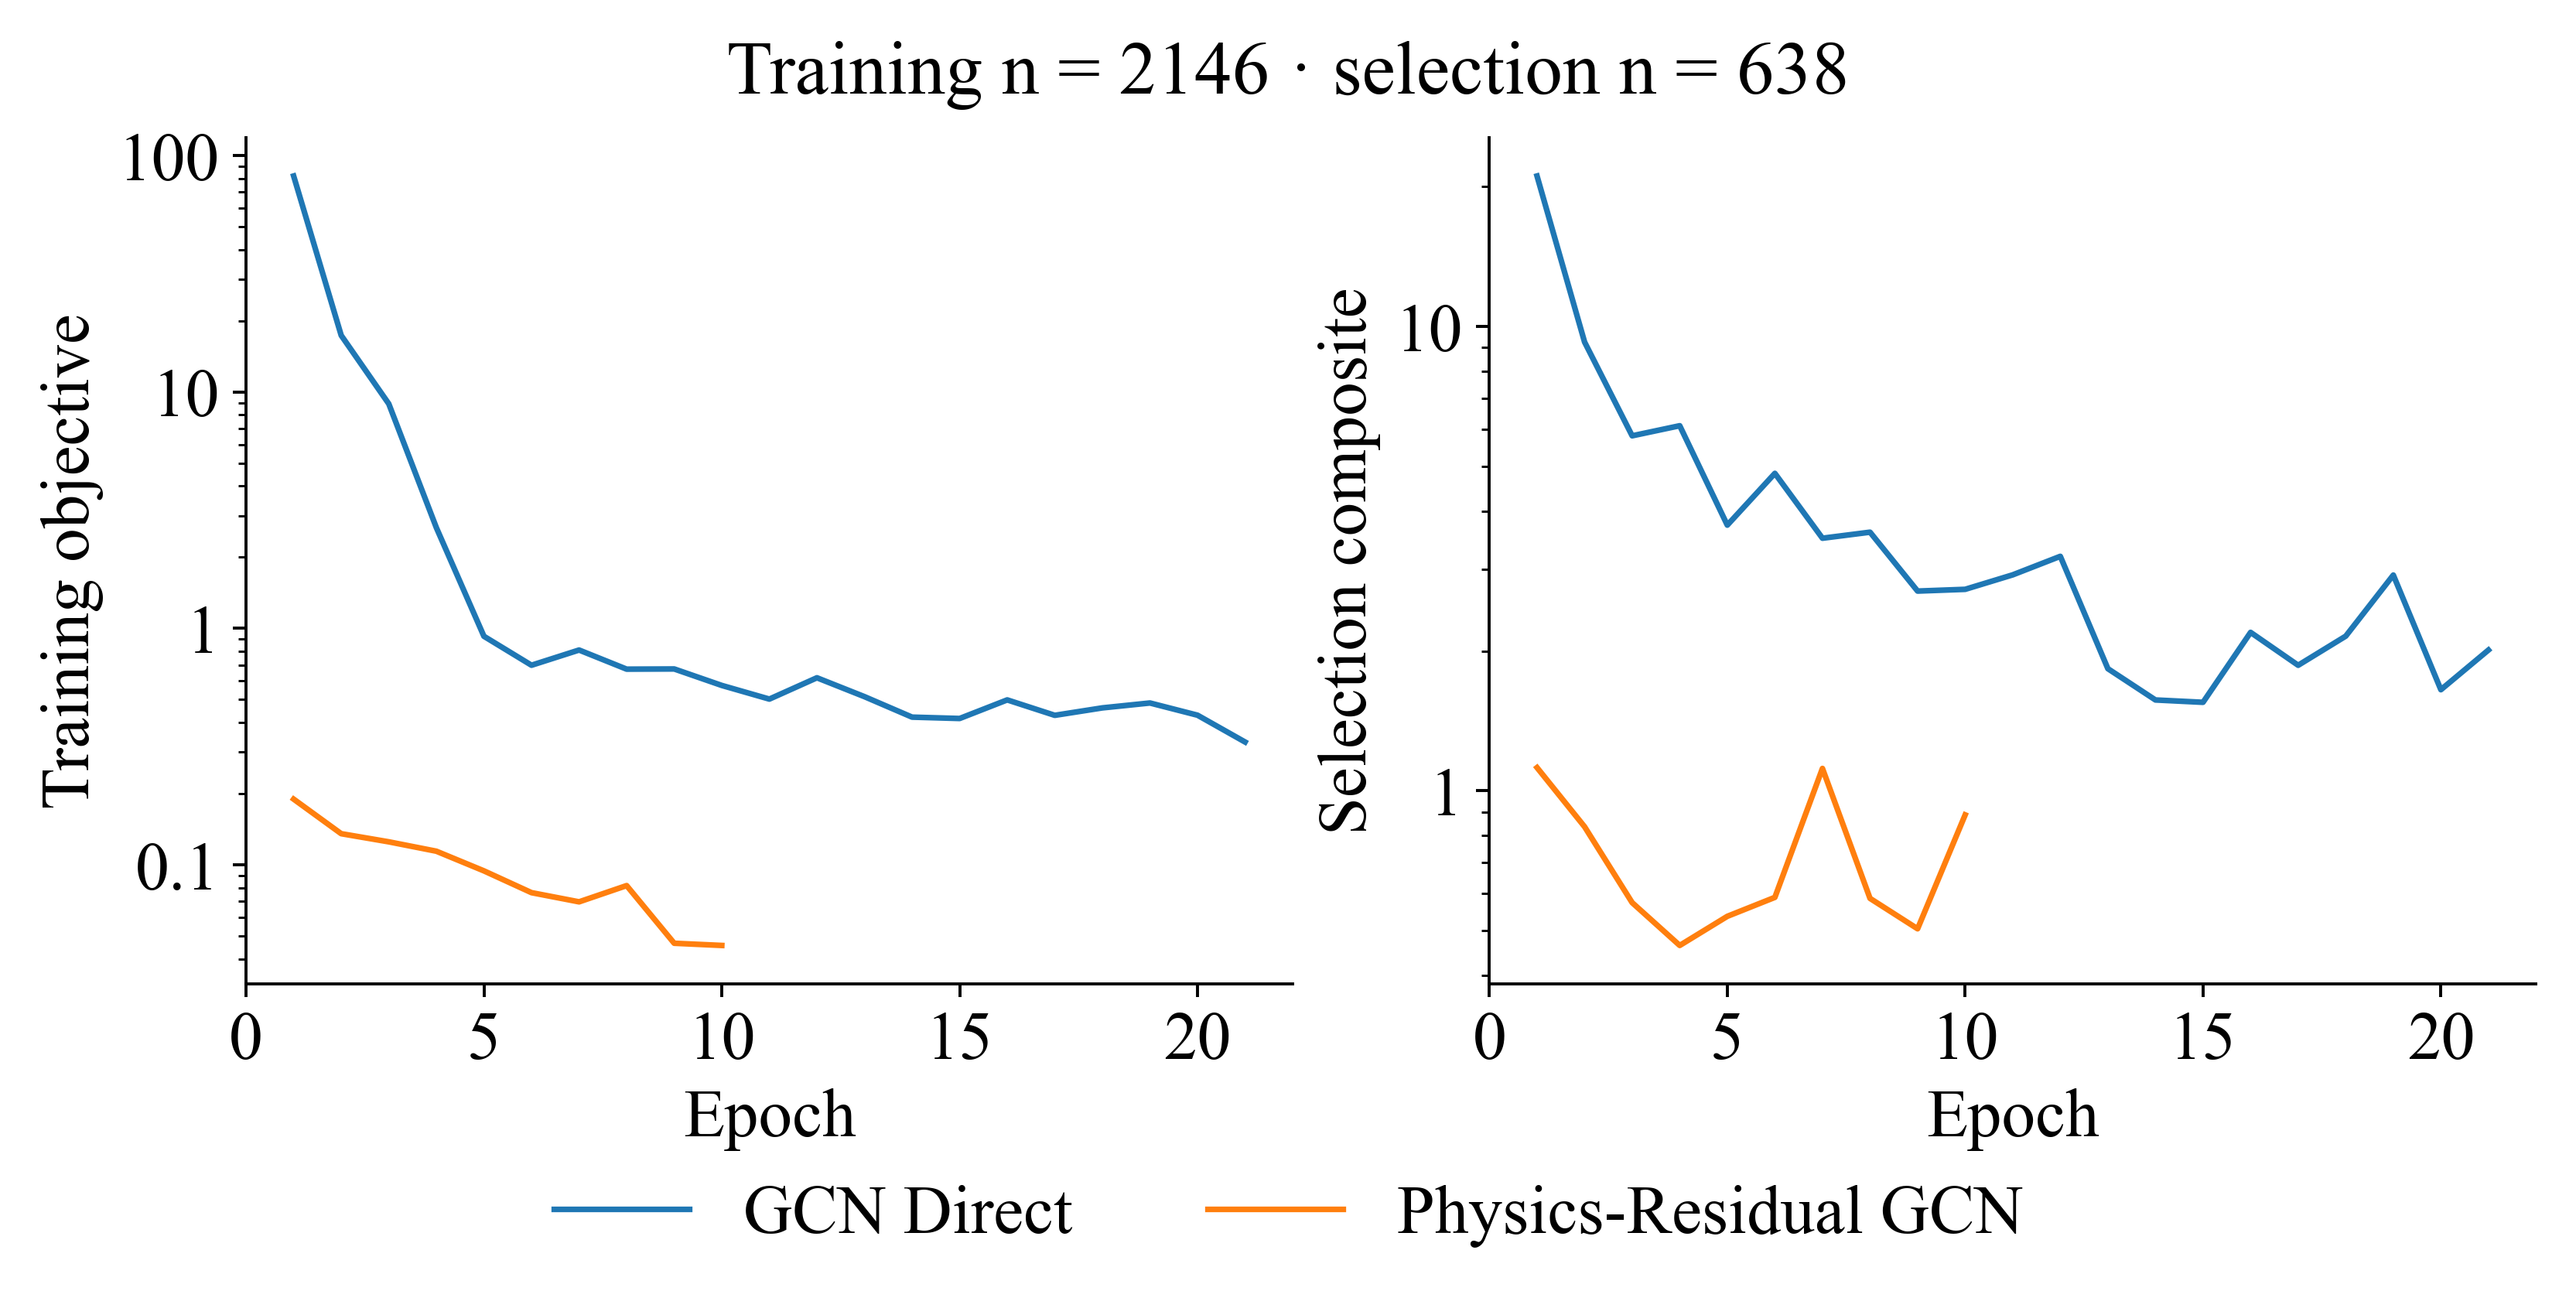

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.3, 4.7), layout="constrained")
for name, trained in graph_models.items():
    history = trained.train_history
    axes[0].plot(history.epoch, history.train_objective, label=name)
    axes[1].plot(history.epoch, history.selection_objective, label=name)
axes[0].set(xlabel="Epoch", ylabel="Training objective")
axes[1].set(xlabel="Epoch", ylabel="Selection composite")
legend_handles, legend_labels = axes[1].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=2, frameon=False)
from matplotlib.ticker import FuncFormatter

for axis in axes:
    axis.set_yscale("log")
    axis.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f"{value:g}"))
fig.suptitle("Training n = 2146 · selection n = 638", fontsize=20)
save_figure(fig, FIGURES / "S3_Graph_comparator_training.png")
plt.show()

The best selection epoch is restored. Equal maximum epochs and patience give a common budget, although actual stopping times and parameter counts differ.

## Data-volume dependence

Training-size sensitivity is compared with and without a physical residual path.

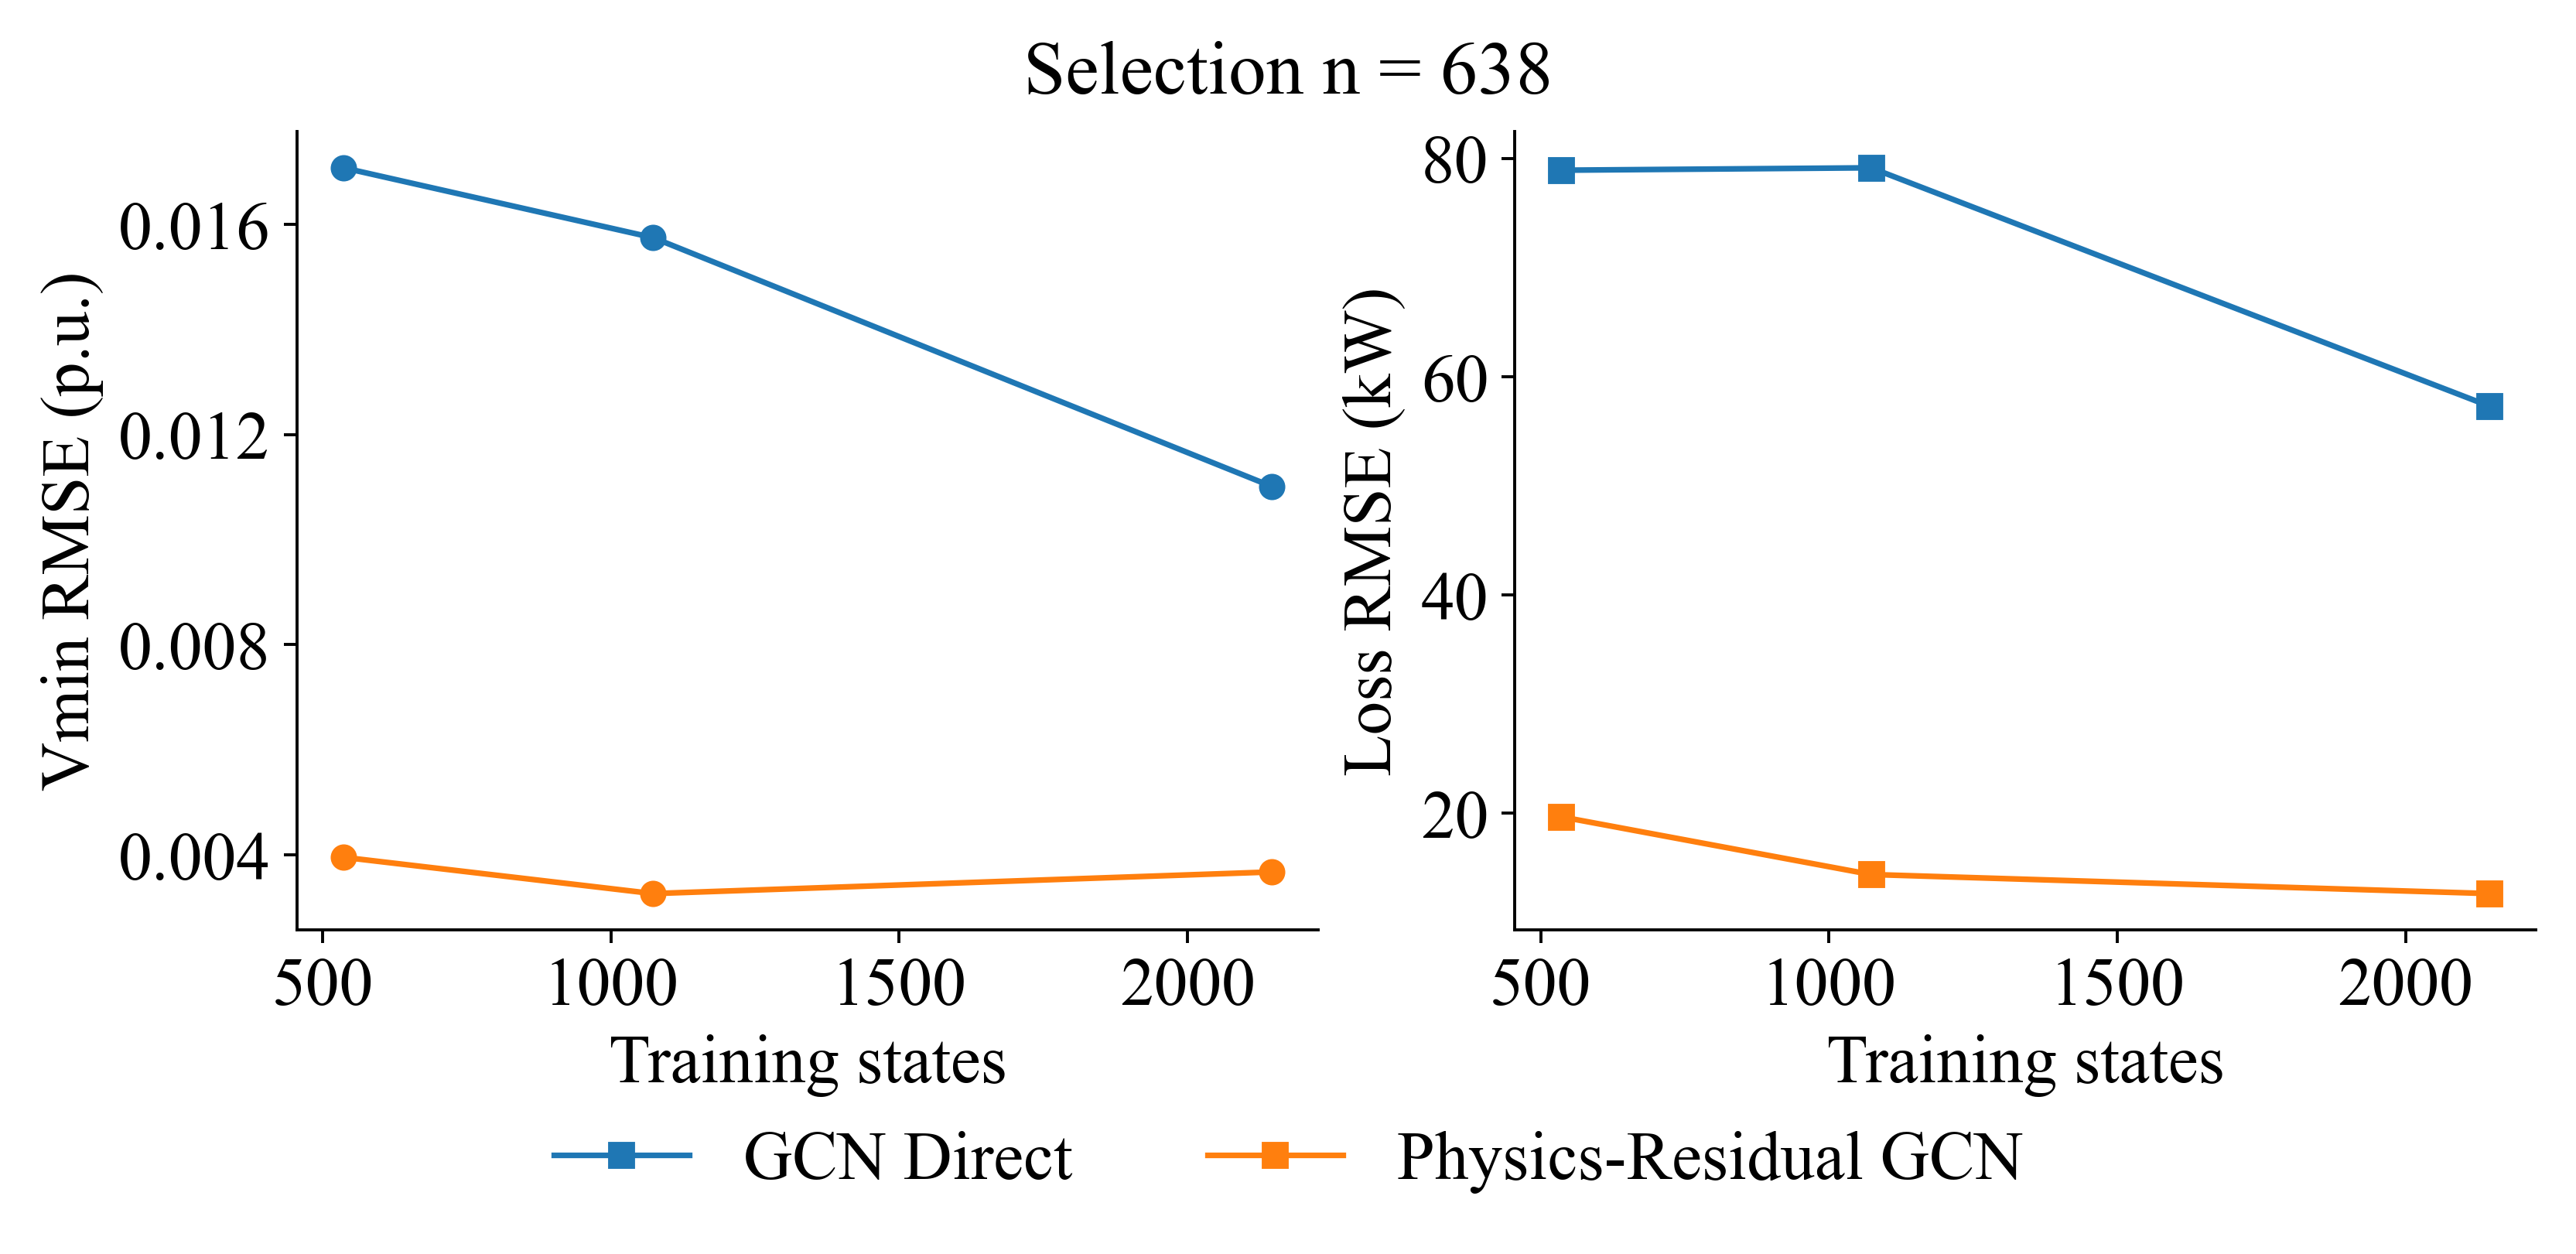

In [8]:
rows = []
for name, configuration in configs.items():
    for fraction in [0.25, 0.5, 1.0]:
        subset = rng.choice(training, int(len(training) * fraction), replace=False)
        trained = train_graph(bundle, subset, indices["selection"], configuration, **TRAINING)
        prediction, _, _ = predict_graph_model(trained, bundle, indices["selection"])
        rows.append(
            dict(
                model=name,
                n=len(subset),
                **regression_metrics(bundle.targets[indices["selection"]], prediction)
            )
        )
curves = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(9.3, 4.5), layout="constrained")
for name, group in curves.groupby("model", sort=False):
    axes[0].plot(group.n, group.vmin_rmse, marker="o", label=name)
    axes[1].plot(group.n, group.loss_rmse_kw, marker="s", label=name)
axes[0].set(xlabel="Training states", ylabel="Vmin RMSE (p.u.)")
axes[1].set(xlabel="Training states", ylabel="Loss RMSE (kW)")
legend_handles, legend_labels = axes[1].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=2, frameon=False)
fig.suptitle("Selection n = 638", fontsize=20)
from matplotlib.ticker import MaxNLocator

for panel in axes:
    panel.xaxis.set_major_locator(MaxNLocator(nbins=4))
    panel.yaxis.set_major_locator(MaxNLocator(nbins=4))
save_figure(fig, FIGURES / "S4_Graph_training_size_curve.png")
plt.show()
curves.to_csv(TABLES / "04_learning_source.csv", index=False)

Training subsets vary the number of observations while retaining the architecture and outer selection set. The curves describe data-volume sensitivity on this feeder.